In [54]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 在这行后面添加：
print(f"检测到 {torch.cuda.device_count()} 个GPU")
train_set = load('../dataresult/train_set')
test_set = load('../dataresult/test_set')
print(train_set.shape)
print(test_set.shape)

# 加载数据集
def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set')
    train_label = load('../dataresult/train_label')
    # 测试集
    test_set = load('../dataresult/test_set')
    test_label = load('../dataresult/test_label')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader



batch_size = 256

# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))


检测到 4 个GPU
torch.Size([3654, 10, 13])
torch.Size([2365, 10, 13])
14
9


In [55]:
# 定义 CNNModel 模型
class CNNModel(nn.Module):
    def __init__(self, input_dim, conv_archs, output_dim):
        """
        预测任务  params:
        input_dim          : 输入数据的维度
        conv_archs         : cnn 网络结构
        output_dim         : 输出维度数
        """
        super().__init__()
        # CNN参数
        self.conv_arch = conv_archs # cnn网络结构
        self.input_channels = input_dim # 输入通道数
        self.cnn_features = self.make_layers()

        # 平局池化
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        # 定义线性层
        self.linear  = nn.Linear(conv_archs[-1][-1], output_dim)
      
    # CNN卷积池化结构
    def make_layers(self):
        layers = []
        for (num_convs, out_channels) in self.conv_arch:
            for _ in range(num_convs):
                layers.append(nn.Conv1d(self.input_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                self.input_channels = out_channels
            # layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)
    def forward(self, input_seq):  
        batch_size = input_seq.size(0)
        # CNN 卷积池化
        # CNN 网络输入[batch, dim, seq_length]
        #改变输入形状
        input_seq = input_seq.permute(0, 2, 1)
        cnn_features = self.cnn_features(input_seq) # torch.Size([32, 64, 1])
        # 平均池化
        x = self.avgpool(cnn_features)          # ttorch.Size([32, 64, 1])
        # 平铺
        flat_tensor = x.view(batch_size, -1) # torch.Size([32, 64])
        predict = self.linear(flat_tensor) 
        return predict

In [56]:
# 定义模型参数
input_dim = 13   # 输入维度为14维数据
# CNN 网络结构 参考经典CNN网络模型 VGG 必看，不然看不懂相关参数设置
conv_archs = ((1, 32), (1, 64))
output_dim = 1 # 输出维度为 1

model = CNNModel(input_dim, conv_archs, output_dim)  

# 在这行后面添加：
# ============ 启用多GPU ============
if torch.cuda.device_count() > 1:
    print(f"🎯 启用 {torch.cuda.device_count()} 个GPU并行训练")
    model = torch.nn.DataParallel(model)
# ===================================

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

🎯 启用 4 个GPU并行训练
  1248
    32
  6144
    64
    64
     1
______
  7553


In [57]:
print(model)

DataParallel(
  (module): CNNModel(
    (cnn_features): Sequential(
      (0): Conv1d(13, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU(inplace=True)
      (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): ReLU(inplace=True)
    )
    (avgpool): AdaptiveAvgPool1d(output_size=1)
    (linear): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [58]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def model_train(model, epochs, loss_function, optimizer, train_loader, test_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
    test_mse = []      # 记录在测试集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
        # 训练
        model.train()

        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数

        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')

        # 每一个epoch结束后，在验证集上验证实验结果。
        with torch.no_grad():
            # 将模型设置为评估模式
            model.eval()

            test_mse_loss = []    #保存当前epoch的MSE loss和
            for data, label in test_loader:
                data, label = data.to(device), label.to(device)
                pre = model(data)
                # 计算损失
                test_loss = loss_function(pre, label)
                test_mse_loss.append(test_loss.item()) 
            
            # 计算总损失
            test_av_mseloss = np.average(test_mse_loss) # 平均
            test_mse.append(test_av_mseloss)
            print(f'Epoch: {epoch+1:2} test_MSE_Loss:{test_av_mseloss:10.8f}')
            
    # 保存最后的参数
    # torch.save(model, 'final_model_cnn.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_cnn.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    # plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    # plt.plot(range(epochs), test_mse, color = 'y',label = 'test_MSE-loss')
    # plt.legend()
    # plt.savefig('./training_loss_curve.png', dpi=150, bbox_inches='tight')
    # print(f"训练损失曲线已保存至: training_loss_curve.png")
    # print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 50
model_train(model, epochs, loss_function, optimizer, train_loader, test_loader, device)

Epoch:  1 train_MSE-Loss: 0.45729522
Epoch:  1 test_MSE_Loss:0.39482224
Epoch:  2 train_MSE-Loss: 0.34974758
Epoch:  2 test_MSE_Loss:0.29974551
Epoch:  3 train_MSE-Loss: 0.26441438
Epoch:  3 test_MSE_Loss:0.21468319
Epoch:  4 train_MSE-Loss: 0.19033758
Epoch:  4 test_MSE_Loss:0.13856692
Epoch:  5 train_MSE-Loss: 0.12683754
Epoch:  5 test_MSE_Loss:0.07893754
Epoch:  6 train_MSE-Loss: 0.07603770
Epoch:  6 test_MSE_Loss:0.04359395
Epoch:  7 train_MSE-Loss: 0.04151757
Epoch:  7 test_MSE_Loss:0.03001023
Epoch:  8 train_MSE-Loss: 0.02376942
Epoch:  8 test_MSE_Loss:0.02682072
Epoch:  9 train_MSE-Loss: 0.01708632
Epoch:  9 test_MSE_Loss:0.02537200
Epoch: 10 train_MSE-Loss: 0.01492124
Epoch: 10 test_MSE_Loss:0.02388986
Epoch: 11 train_MSE-Loss: 0.01410901
Epoch: 11 test_MSE_Loss:0.02270586
Epoch: 12 train_MSE-Loss: 0.01366404
Epoch: 12 test_MSE_Loss:0.02184510
Epoch: 13 train_MSE-Loss: 0.01333180
Epoch: 13 test_MSE_Loss:0.02117912
Epoch: 14 train_MSE-Loss: 0.01306097
Epoch: 14 test_MSE_Loss:0.0

### 第一部分，训练集评估

In [59]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

/tmp/ipykernel_2741351/2190353117.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_cnn.pt')


In [60]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.8923718820635184
**************************************************
训练数据集上的均方误差-MSE:  0.008596063252084273
训练数据集上的均方根误差-RMSE:  0.092714957003087
训练数据集上的平均绝对误差-MAE:  0.06386275090514866


# 测试集评估

In [61]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test_pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test_pre_data += pred        

/tmp/ipykernel_2741351/1945682226.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_cnn.pt')


In [62]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test_pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test_pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test_pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: 0.8330838735660814
**************************************************
测试数据集上的均方误差-MSE:  0.01309045349254332
测试数据集上的均方根误差-RMSE:  0.11441351971049278
测试数据集上的平均绝对误差-MAE:  0.08807153842483079


In [77]:
import numpy as np
import torch
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from thop import profile

# ==================== 1. 模型预处理（关键！放在最前） ====================
# 解除DataParallel包装 + 统一设备 + eval模式（避免后续所有设备问题）
model = model.module if isinstance(model, torch.nn.DataParallel) else model
model = model.to(device).eval()  # 一次性解决所有设备冲突

# ==================== 2. 回归指标计算 ====================
def calculate_regression_metrics(y_true, y_pred, epsilon=1e-8):
    def to_numpy_1d(x):
        if isinstance(x, list): x = np.array(x)
        elif isinstance(x, torch.Tensor): x = x.detach().cpu().numpy()
        return np.array(x).flatten() if not isinstance(x, np.ndarray) else x.flatten()

    y_true, y_pred = to_numpy_1d(y_true), to_numpy_1d(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': round(mse, 6),
        'MAE': round(mean_absolute_error(y_true, y_pred), 6),
        'RMSE': round(np.sqrt(mse), 6),
        'MAPE(%)': round(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100, 4),
        'R2': round(r2_score(y_true, y_pred), 6)
    }

metrics = calculate_regression_metrics(test_origin_data, test_pre_data)
print("✅ 测试集指标:", metrics)

# ==================== 3. 参数量统计（修复DataParallel重复计数问题） ====================
def count_model_params(model):
    return {
        'total_params': sum(p.numel() for p in model.parameters()),
        'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

params_info = count_model_params(model)  # 此时model已是纯净原始模型
print(f"✅ 总参数量: {params_info['total_params']:,} ({params_info['total_params']/1e6:.2f} M)")

# ==================== 4. FLOPs计算 ====================
def get_flops_thop(model, input_sample):
    with torch.no_grad():
        flops, _ = profile(model, inputs=(input_sample,), verbose=False)
    return flops

dummy_input = torch.randn(1, 10, 13).to(device)  # PHM2012窗口=10
flops = get_flops_thop(model, dummy_input)
print(f"✅ FLOPs: {flops:,.0f} ({flops/1e6:.2f} MFLOPs)")

# ==================== 5. 推理延迟测量 ====================
x = torch.randn(1, 10, 13).to(device)
for _ in range(50): _ = model(x)  # 预热
start = time.time()
for _ in range(100): _ = model(x)
if device.type == 'cuda': torch.cuda.synchronize()
latency_ms = (time.time() - start) / 100 * 1000
print(f"✅ 单样本推理延迟: {latency_ms:.2f} ms")

✅ 测试集指标: {'MSE': 0.01309, 'MAE': 0.088072, 'RMSE': 0.114414, 'MAPE(%)': 25.8764, 'R2': 0.833084}
✅ 总参数量: 7,553 (0.01 M)
✅ FLOPs: 74,688 (0.07 MFLOPs)
✅ 单样本推理延迟: 0.24 ms


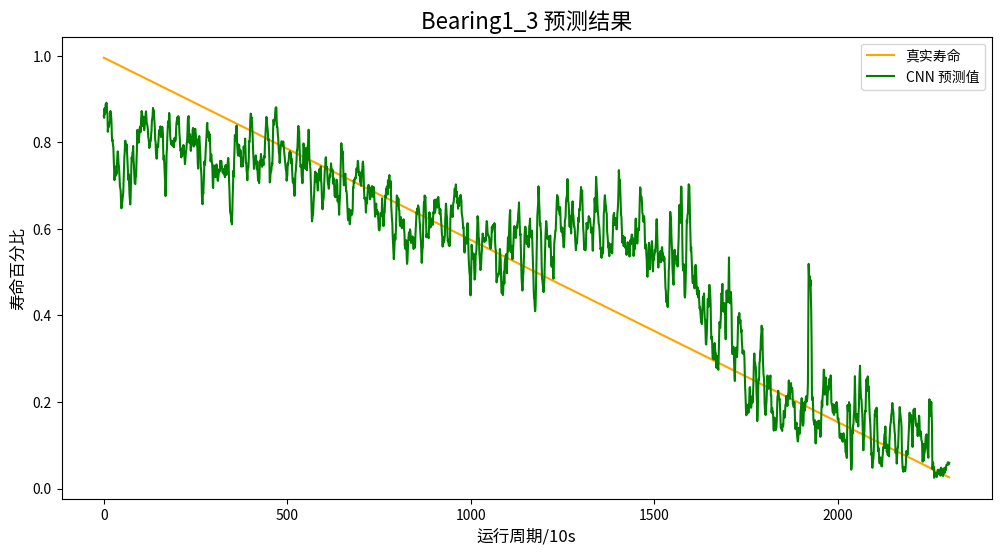

['../相关可视化/cnn_pre']

In [66]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test_pre_data, label='CNN 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../相关可视化/cnn_origin') 
dump(test_pre_data, '../相关可视化/cnn_pre')

In [67]:
print(len(test_origin_data))
print(len(test_pre_data))

2304
2304


CNN test function: Y = 0.1287 + 0.7798 *X.


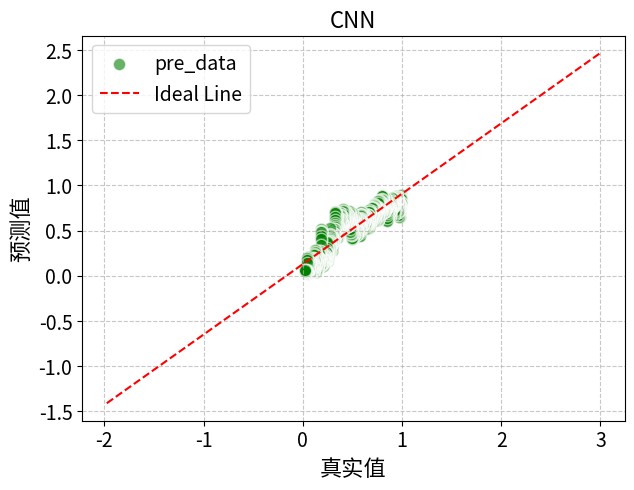

In [68]:
from sklearn.linear_model import LinearRegression

test_y = np.array(test_origin_data).reshape(-1)
pred = test_pre_data
ylow = np.min(test_y) - 2
yhigh = np.max(test_y) + 2
x_center = np.mean(test_y)
y_center = np.mean(pred)
xline_test = np.linspace(ylow, yhigh, 50)
lr_test = LinearRegression()
lr_test.fit(test_y.reshape(-1, 1), pred)
yline_test = lr_test.predict(xline_test.reshape(-1, 1))
test_coef = round(lr_test.coef_[0][0], 4)
test_bias = round(lr_test.intercept_[0], 4)
y_test_func = 'Y = ' + str(test_bias) + ' + ' + str(test_coef) + ' *X'
print(f'CNN test function: {y_test_func}.')
plt.figure(figsize=(7, 5))
plt.title('CNN',fontsize=16)

# 用透明度和不同颜色增强可视化效果
plt.scatter(test_y, pred, color='green', alpha=0.6, edgecolors='w', s=80, label='pre_data')
plt.plot(xline_test, yline_test, 'r--', label='Ideal Line')

plt.ylabel('预测值', fontsize=16)
plt.xlabel('真实值', fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加图例
plt.legend(fontsize=14)

# 显示图表
plt.show()